In [1]:
from bs4 import BeautifulSoup
import time
import urllib.request
import requests
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import os
from keras.models import load_model
from cvimgtest import Deal_With_TestImg
import h5py as h5
import scipy.io
import time

Using TensorFlow backend.


##THSR抓圖區

In [2]:
#不建議使用mp，抓太快會被高鐵網站ban，32G記憶體約能一次抓100張
def Crawler(model,count):
    session = requests.Session()
    response = session.get('https://irs.thsrc.com.tw/IMINT/', headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/81.0.4044.138 Safari/537.36'})
    source = response.content.decode('utf-8')
    soup = BeautifulSoup(source, 'html.parser')
    img = soup.find('img')
    url = 'https://irs.thsrc.com.tw'+img.get('src')
    print(url)
    response = session.get(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/81.0.4044.138 Safari/537.36'})
    with open('D:/DLmidterm/crawltest/'+str(count)+'.jpg', 'wb') as file:
        file.write(response.content)
        file.flush()
    img=np.asarray(Image.open('D:/DLmidterm/crawltest/'+str(count)+'.jpg'))
    img=Deal_With_TestImg(count,img,'crawltest')
    x = np.expand_dims(img,axis=0)/255
    x = np.argmax(model.predict(x),axis=2)
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt=[datasheet[str(i[0])]for i in x] #預測為['A','B','C','D']

    filename=pdt[0]+pdt[1]+pdt[2]+pdt[3]
    if not os.path.exists('D:/DLmidterm/crawltest/'+filename+'.jpg'):
        os.rename('D:/DLmidterm/crawltest/'+str(count)+'.jpg','D:/DLmidterm/crawltest/'+filename+'.jpg')
    else:
        os.remove('D:/DLmidterm/crawltest/'+str(count)+'.jpg')


In [4]:
def CrawlerTHSR_TO_Testdataset():
    model=load_model('D:/DLmidterm/models/RMSprop-11-0.9952.h5')
    count=0
    while (count<=100):
        Crawler(model,count)
        count += 1
CrawlerTHSR_TO_Testdataset()

https://irs.thsrc.com.tw/IMINT/captImg/ll77rmn6A0.jpg
now is dealing with: 0
https://irs.thsrc.com.tw/IMINT/captImg/31BvtPePae.jpg
now is dealing with: 1
https://irs.thsrc.com.tw/IMINT/captImg/600NQuJMcL.jpg
now is dealing with: 2
https://irs.thsrc.com.tw/IMINT/captImg/jJPuzW7Mnt.jpg
now is dealing with: 3
https://irs.thsrc.com.tw/IMINT/captImg/aPFBxUNjtn.jpg
now is dealing with: 4
https://irs.thsrc.com.tw/IMINT/captImg/9dTcS4nuY8.jpg
now is dealing with: 5
https://irs.thsrc.com.tw/IMINT/captImg/Vz5XFmXB7d.jpg
now is dealing with: 6
https://irs.thsrc.com.tw/IMINT/captImg/C6v9phQcYn.jpg
now is dealing with: 7
https://irs.thsrc.com.tw/IMINT/captImg/LNQ6fL95yT.jpg
now is dealing with: 8
https://irs.thsrc.com.tw/IMINT/captImg/y2Iqt82VCM.jpg
now is dealing with: 9
https://irs.thsrc.com.tw/IMINT/captImg/FHSxJ8UCgV.jpg
now is dealing with: 10
https://irs.thsrc.com.tw/IMINT/captImg/ZLxZXFecdb.jpg
now is dealing with: 11
https://irs.thsrc.com.tw/IMINT/captImg/jJPuzW7Mnt.jpg
now is dealing with:

##owntest測試區

C:\Users\苯異丙胺\AppData\Local\Programs\Python\Python37\lib\site-packages\ipykernel_launcher.py:8: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  


number  0
prdict= ['2', '2', 'A', 'M']
answer= ['2', '2', 'A', 'M']
number  1
prdict= ['2', '2', 'K', 'N']
answer= ['2', '2', 'K', 'N']
number  2
prdict= ['2', '4', '2', 'M']
answer= ['2', '4', '2', 'M']
number  3
prdict= ['2', '4', 'K', '2']
answer= ['2', '4', 'K', '2']
number  4
prdict= ['2', '4', 'Z', 'H']
answer= ['2', '4', 'Z', 'H']
number  5
prdict= ['2', '7', '9', 'Z']
answer= ['2', '7', '9', 'Z']
number  6
prdict= ['2', '7', 'N', '4']
answer= ['2', '7', 'N', '4']
number  7
prdict= ['2', '7', 'Y', 'M']
answer= ['2', '7', 'Y', 'M']
number  8
prdict= ['2', '9', 'N', 'Y']
answer= ['2', '9', 'N', 'Y']
number  9
prdict= ['2', '9', 'P', '5']
answer= ['2', '9', 'P', '5']
number  10
prdict= ['2', '9', 'T', 'M']
answer= ['2', '9', 'T', 'M']
number  11
prdict= ['2', 'A', '4', 'R']
answer= ['2', 'A', '4', 'R']
number  12
prdict= ['2', 'A', 'P', '3']
answer= ['2', 'A', 'P', '3']
number  13
prdict= ['2', 'C', '9', 'Z']
answer= ['2', 'C', '9', 'Z']
number  14
prdict= ['2', 'C', 'H', 'N']
answ

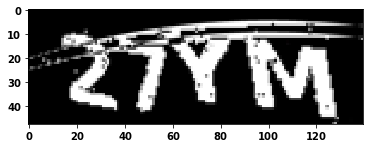

number  31
prdict= ['2', '7', 'Y', 'M']
answer= ['2', 'Y', 'Y', 'M']
number  32
prdict= ['2', 'Z', '2', '2']
answer= ['2', 'Z', '2', '2']
number  33
prdict= ['2', 'Z', 'N', '9']
answer= ['2', 'Z', 'N', '9']
number  34
prdict= ['2', 'Z', 'Z', 'P']
answer= ['2', 'Z', 'Z', 'P']
number  35
prdict= ['3', '2', '9', 'K']
answer= ['3', '2', '9', 'K']
number  36
prdict= ['3', '2', 'H', '9']
answer= ['3', '2', 'H', '9']
number  37
prdict= ['3', '3', 'F', 'K']
answer= ['3', '3', 'F', 'K']
number  38
prdict= ['3', '3', 'Z', '5']
answer= ['3', '3', 'Z', '5']
number  39
prdict= ['3', '4', '2', 'K']
answer= ['3', '4', '2', 'K']
number  40
prdict= ['3', '4', 'C', 'H']
answer= ['3', '4', 'C', 'H']
number  541
prdict= ['R', 'T', 'Q', 'M']
answer= ['R', 'F', 'Q', 'M']


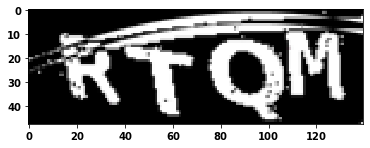

number  632
prdict= ['T', 'Z', '4', 'P']
answer= ['Y', 'Z', '4', 'P']


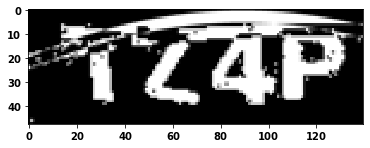

672 picture total wrong=3
one word accuracy= 0.9988839285714286
four word accuracy= 0.9955357142857143
0.0
15.684248447418213
0.002000570297241211


In [2]:
#測試owntest
#先把model load進來
model1=load_model("D:/DLmidterm/checkpoint/Adamax-10-0.9920.h5")
model2=load_model("D:/DLmidterm/checkpoint/Adamax-18-0.9920.h5")
model3=load_model("D:/DLmidterm/checkpoint/RMSprop-11-0.9952.h5")
#將y_onehot和x_test變成global加快速度
with h5.File('D:/DLmidterm/owntest.h5','r') as file:
        x_test=file.get("x").value/255
data=scipy.io.loadmat("D:/DLmidterm/owntest.mat")
y_onehot=data['y_onehot']
filenum=x_test.shape[0]
def ThreeModelTestOwn(model1,model2,model3):
    global filenum
    time_start1=time.time()
    l=[]
    time_end1=time.time()
    time_start2=time.time()
    for i in range(filenum):
        imacc,facc=ThreeModelPredict(model1,model2,model3,i)
        l.append((imacc,facc))
    time_end2=time.time()
    time_start3=time.time()
    sigma=np.asarray(np.sum(np.asarray(l),axis=0))
    imgaccuracy=sigma[0]/filenum
    fourwordccuracy=sigma[1]/(4*filenum)
    print('%d picture total wrong=%d'%(filenum,4*filenum-sigma[1]))
    print('one word accuracy=',fourwordccuracy)
    print('four word accuracy=',imgaccuracy)  
    time_end3=time.time()
    print(time_end1-time_start1)
    print(time_end2-time_start2)
    print(time_end3-time_start3)

def ThreeModelPredict(model1,model2,model3,count):
    global y_onehot,x_test
    y=y_onehot.reshape((int(y_onehot.shape[0]/4),4,19))
    img = x_test[count]
    img = np.expand_dims(img,axis=0)       
    x1,x2,x3=EeachModelPredict(model1,model2,model3,img)
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt1=[datasheet[str(i[0])]for i in x1] #預測為['A','B','C','D']
    pdt2=[datasheet[str(i[0])]for i in x2]
    pdt3=[datasheet[str(i[0])]for i in x3]
    ans=[datasheet[str(np.argmax(y[count][i]))] for i in range(4)]#答案為['A','B','C','D']
    fouracc=0
    imgacc=0
    #處理三個網路預測的結果，分析哪個為最終結果
    if pdt1==pdt2==pdt3:
        pdt=pdt1
    elif pdt1==pdt2:
        pdt=pdt1
    elif pdt1==pdt3:  
        pdt=pdt1
    elif pdt2==pdt3:  
        pdt=pdt2
    else:
        pdt=pdt3
    #確認有幾個字對
    for ind,letter in enumerate(pdt):
        if letter==ans[ind]:
            fouracc+=1
        else:
            plt.imshow(x_test[count])
            print("number ",count)
            print("prdict=",pdt)
            print("answer=",ans)
            plt.show()
    if pdt==ans:
        imgacc=1
    if count <=40:
        print("number ",count)
        print("prdict=",pdt)
        print("answer=",ans)
    return imgacc,fouracc

def EeachModelPredict(model1,model2,model3,img):
    x1 = np.argmax(model1.predict(img),axis=2) #x1:Adamax-10-0.9920.h5
    x2 = np.argmax(model2.predict(img),axis=2) #x2:Adamax-18-0.9920.h5
    x3 = np.argmax(model3.predict(img),axis=2) #x3:RMSprop-11-0.9952.h5
    return x1,x2,x3
ThreeModelTestOwn(model1,model2,model3)    
    

C:\Users\苯異丙胺\AppData\Local\Programs\Python\Python37\lib\site-packages\ipykernel_launcher.py:4: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  after removing the cwd from sys.path.


number  0
prdict= ['2', '2', 'A', 'M']
answer= ['2', '2', 'A', 'M']
number  1
prdict= ['2', '2', 'K', 'N']
answer= ['2', '2', 'K', 'N']
number  2
prdict= ['2', '4', 'K', '2']
answer= ['2', '4', 'K', '2']
number  3
prdict= ['2', '4', 'Z', 'H']
answer= ['2', '4', 'Z', 'H']
number  4
prdict= ['2', '7', '9', 'Z']
answer= ['2', '7', '9', 'Z']
number  5
prdict= ['2', 'Y', 'Y', 'M']
answer= ['2', '7', 'Y', 'M']


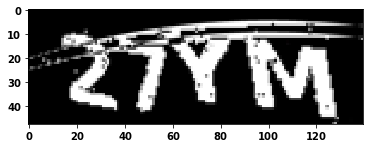

number  5
prdict= ['2', 'Y', 'Y', 'M']
answer= ['2', '7', 'Y', 'M']
number  6
prdict= ['2', '9', 'N', 'Y']
answer= ['2', '9', 'N', 'Y']
number  7
prdict= ['2', '9', 'T', 'M']
answer= ['2', '9', 'T', 'M']
number  8
prdict= ['2', 'A', 'P', '3']
answer= ['2', 'A', 'P', '3']
number  9
prdict= ['2', 'C', '9', 'Z']
answer= ['2', 'C', '9', 'Z']
number  10
prdict= ['2', 'C', 'H', 'N']
answer= ['2', 'C', 'H', 'N']
number  11
prdict= ['2', 'C', 'Q', '5']
answer= ['2', 'C', 'Q', '5']
number  12
prdict= ['2', 'F', '5', '3']
answer= ['2', 'F', '5', '3']
number  13
prdict= ['2', 'H', 'N', 'K']
answer= ['2', 'H', 'N', 'K']
number  14
prdict= ['2', 'K', 'N', 'A']
answer= ['2', 'K', 'N', 'A']
number  15
prdict= ['2', 'K', 'Z', '9']
answer= ['2', 'K', 'Z', '9']
number  16
prdict= ['2', 'M', 'Z', '4']
answer= ['2', 'M', 'Z', '4']
number  17
prdict= ['2', 'N', '9', 'C']
answer= ['2', 'N', '9', 'C']
number  18
prdict= ['2', 'N', 'A', '4']
answer= ['2', 'N', 'A', '4']
number  19
prdict= ['2', 'N', 'Q', 'Z']

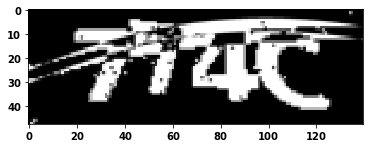

number  444
prdict= ['Y', 'Z', '4', 'P']
answer= ['T', 'Z', '4', 'P']


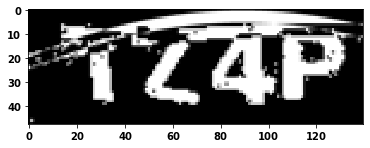

507 picture total wrong=3
one word accuracy= 0.9985207100591716
four word accuracy= 0.9940828402366864
0.0
4.048688650131226
0.0010013580322265625


In [2]:
#一個model預測owntest
model=load_model("D:/DLmidterm/checkpoint/RMSprop-11-0.9952.h5")
with h5.File('D:/DLmidterm/owntest.h5','r') as file:
        x_test=file.get("x").value/255
data=scipy.io.loadmat("D:/DLmidterm/owntest.mat")
y_onehot=data['y_onehot']
filenum=x_test.shape[0]
def OneModelTestOwn(model):
    global filenum
    time_start1=time.time()
    l=[]

    time_end1=time.time()
    time_start2=time.time()
    for i in range(filenum):
        imacc,facc=OneModelPredict(model,i)
        l.append((imacc,facc))
    time_end2=time.time()
    time_start3=time.time()
    sigma=np.asarray(np.sum(np.asarray(l),axis=0))
    imgaccuracy=sigma[0]/filenum
    fourwordccuracy=sigma[1]/(4*filenum)
    print('%d picture total wrong=%d'%(filenum,4*filenum-sigma[1]))
    print('one word accuracy=',fourwordccuracy)
    print('four word accuracy=',imgaccuracy)  
    time_end3=time.time()
    print(time_end1-time_start1)
    print(time_end2-time_start2)
    print(time_end3-time_start3)

def OneModelPredict(model,count):
    global y_onehot,x_test
    y=y_onehot.reshape((int(y_onehot.shape[0]/4),4,19))
    img = x_test[count]
    img = np.expand_dims(img,axis=0) 
    x1 = np.argmax(model.predict(img),axis=2) 
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt=[datasheet[str(i[0])]for i in x1] #預測為['A','B','C','D']
    ans=[datasheet[str(np.argmax(y[count][i]))] for i in range(4)]#答案為['A','B','C','D']
    fouracc=0
    imgacc=0

    #確認有幾個字對
    for ind,letter in enumerate(pdt):
        if letter==ans[ind]:
            fouracc+=1
        else:
            plt.imshow(x_test[count])
            print("number ",count)
            print("prdict=",pdt)
            print("answer=",ans)
            plt.show()
    if pdt==ans:
        imgacc=1
    if count <=40:
        print("number ",count)
        print("prdict=",pdt)
        print("answer=",ans)
    return imgacc,fouracc
OneModelTestOwn(model)

    
    

##train測試區

In [118]:
#測試train
#先把model load進來
model1=load_model("D:/DLmidterm/checkpoint/Adamax-10-0.9920.h5")
model2=load_model("D:/DLmidterm/checkpoint/Adamax-18-0.9920.h5")
model3=load_model("D:/DLmidterm/checkpoint/RMSprop-11-0.9952.h5")
#將y_onehot和x_test變成global加快速度
with h5.File('D:/DLmidterm/train.h5','r') as file:
        x_test=file.get("x").value/255
data=scipy.io.loadmat("D:/DLmidterm/train.mat")
y_onehot=data['y_onehot']
filenum=x_test.shape[0]
def ThreeModelTestTrain(model1,model2,model3):
    global filenum
    time_start1=time.time()
    l=[]
    time_end1=time.time()
    time_start2=time.time()
    for i in range(filenum):
        imacc,facc=ThreeModelPredict(model1,model2,model3,i)
        l.append((imacc,facc))
    time_end2=time.time()
    time_start3=time.time()
    sigma=np.asarray(np.sum(np.asarray(l),axis=0))
    imgaccuracy=sigma[0]/filenum
    fourwordccuracy=sigma[1]/(4*filenum)
    print('%d picture total wrong=%d'%(filenum,4*filenum-sigma[1]))
    print('one word accuracy=',fourwordccuracy)
    print('four word accuracy=',imgaccuracy)  
    time_end3=time.time()
    print(time_end1-time_start1)
    print(time_end2-time_start2)
    print(time_end3-time_start3)

def ThreeModelPredict(model1,model2,model3,count):
    global y_onehot,x_test
    y=y_onehot.reshape((int(y_onehot.shape[0]/4),4,19))
    img = x_test[count]
    img = np.expand_dims(img,axis=0)       
    x1,x2,x3=EeachModelPredict(model1,model2,model3,img)
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt1=[datasheet[str(i[0])]for i in x1] #預測為['A','B','C','D']
    pdt2=[datasheet[str(i[0])]for i in x2]
    pdt3=[datasheet[str(i[0])]for i in x3]
    ans=[datasheet[str(np.argmax(y[count][i]))] for i in range(4)]#答案為['A','B','C','D']
    fouracc=0
    imgacc=0
    #處理三個網路預測的結果，分析哪個為最終結果
    if pdt1==pdt2==pdt3:
        pdt=pdt1
    elif pdt1==pdt2:
        pdt=pdt1
    elif pdt1==pdt3:  
        pdt=pdt1
    elif pdt2==pdt3:  
        pdt=pdt2
    else:
        pdt=pdt3
    #確認有幾個字對
    for ind,letter in enumerate(pdt):
        if letter==ans[ind]:
            fouracc+=1
        else:
            plt.imshow(x_test[count])
            print("number ",count)
            print("prdict=",pdt)
            print("answer=",ans)
            plt.show()
    if pdt==ans:
        imgacc=1
    if count <=40:
        print("number ",count)
        print("prdict=",pdt)
        print("answer=",ans)
    return imgacc,fouracc

def EeachModelPredict(model1,model2,model3,img):
    x1 = np.argmax(model1.predict(img),axis=2) #x1:Adamax-10-0.9920.h5
    x2 = np.argmax(model2.predict(img),axis=2) #x2:Adamax-18-0.9920.h5
    x3 = np.argmax(model3.predict(img),axis=2) #x3:RMSprop-11-0.9952.h5
    return x1,x2,x3
ThreeModelTestTrain(model1,model2,model3)    
    

##測試test

In [ ]:
#一個model預測test
model=load_model("D:/DLmidterm/checkpoint/RMSprop-11-0.9952.h5")
with h5.File('D:/DLmidterm/test.h5','r') as file:
        x_test=file.get("x").value/255
data=scipy.io.loadmat("D:/DLmidterm/test.mat")
y_onehot=data['y_onehot']
filenum=x_test.shape[0]
def OneModelTestOwn(model):
    global filenum
    time_start1=time.time()
    l=[]
    time_end1=time.time()
    time_start2=time.time()
    for i in range(filenum):
        imacc,facc=OneModelPredict(model,i)
        l.append((imacc,facc))
    time_end2=time.time()
    time_start3=time.time()
    sigma=np.asarray(np.sum(np.asarray(l),axis=0))
    imgaccuracy=sigma[0]/filenum
    fourwordccuracy=sigma[1]/(4*filenum)
    print('%d picture total wrong=%d'%(filenum,4*filenum-sigma[1]))
    print('one word accuracy=',fourwordccuracy)
    print('four word accuracy=',imgaccuracy)  
    time_end3=time.time()
    print(time_end1-time_start1)
    print(time_end2-time_start2)
    print(time_end3-time_start3)

def OneModelPredict(model,count):
    global y_onehot,x_test
    y=y_onehot.reshape((int(y_onehot.shape[0]/4),4,19))
    img = x_test[count]
    img = np.expand_dims(img,axis=0) 
    x1 = np.argmax(model.predict(img),axis=2) 
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt=[datasheet[str(i[0])]for i in x1] #預測為['A','B','C','D']
    ans=[datasheet[str(np.argmax(y[count][i]))] for i in range(4)]#答案為['A','B','C','D']
    fouracc=0
    imgacc=0

    #確認有幾個字對
    for ind,letter in enumerate(pdt):
        if letter==ans[ind]:
            fouracc+=1
        else:
            plt.imshow(x_test[count])
            print("number ",count)
            print("prdict=",pdt)
            print("answer=",ans)
            plt.show()
    if pdt==ans:
        imgacc=1
    if count <=40:
        print("number ",count)
        print("prdict=",pdt)
        print("answer=",ans)
    return imgacc,fouracc
OneModelTestOwn(model)

    
    

In [ ]:
#測試train
#先把model load進來
model1=load_model("D:/DLmidterm/checkpoint/Adamax-10-0.9920.h5")
model2=load_model("D:/DLmidterm/checkpoint/Adamax-18-0.9920.h5")
model3=load_model("D:/DLmidterm/checkpoint/RMSprop-11-0.9952.h5")
#將y_onehot和x_test變成global加快速度
with h5.File('D:/DLmidterm/test.h5','r') as file:
        x_test=file.get("x").value/255
data=scipy.io.loadmat("D:/DLmidterm/test.mat")
y_onehot=data['y_onehot']
filenum=x_test.shape[0]
def ThreeModelTestTrain(model1,model2,model3):
    global filenum
    time_start1=time.time()
    l=[]
    time_end1=time.time()
    time_start2=time.time()
    for i in range(filenum):
        imacc,facc=ThreeModelPredict(model1,model2,model3,i)
        l.append((imacc,facc))
    time_end2=time.time()
    time_start3=time.time()
    sigma=np.asarray(np.sum(np.asarray(l),axis=0))
    imgaccuracy=sigma[0]/filenum
    fourwordccuracy=sigma[1]/(4*filenum)
    print('%d picture total wrong=%d'%(filenum,4*filenum-sigma[1]))
    print('one word accuracy=',fourwordccuracy)
    print('four word accuracy=',imgaccuracy)  
    time_end3=time.time()
    print(time_end1-time_start1)
    print(time_end2-time_start2)
    print(time_end3-time_start3)

def ThreeModelPredict(model1,model2,model3,count):
    global y_onehot,x_test
    y=y_onehot.reshape((int(y_onehot.shape[0]/4),4,19))
    img = x_test[count]
    img = np.expand_dims(img,axis=0)       
    x1,x2,x3=EeachModelPredict(model1,model2,model3,img)
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt1=[datasheet[str(i[0])]for i in x1] #預測為['A','B','C','D']
    pdt2=[datasheet[str(i[0])]for i in x2]
    pdt3=[datasheet[str(i[0])]for i in x3]
    ans=[datasheet[str(np.argmax(y[count][i]))] for i in range(4)]#答案為['A','B','C','D']
    fouracc=0
    imgacc=0
    #處理三個網路預測的結果，分析哪個為最終結果
    if pdt1==pdt2==pdt3:
        pdt=pdt1
    elif pdt1==pdt2:
        pdt=pdt1
    elif pdt1==pdt3:  
        pdt=pdt1
    elif pdt2==pdt3:  
        pdt=pdt2
    else:
        pdt=pdt3
    #確認有幾個字對
    for ind,letter in enumerate(pdt):
        if letter==ans[ind]:
            fouracc+=1
        else:
            plt.imshow(x_test[count])
            print("number ",count)
            print("prdict=",pdt)
            print("answer=",ans)
            plt.show()
    if pdt==ans:
        imgacc=1
    if count <=40:
        print("number ",count)
        print("prdict=",pdt)
        print("answer=",ans)
    return imgacc,fouracc

def EeachModelPredict(model1,model2,model3,img):
    x1 = np.argmax(model1.predict(img),axis=2) #x1:Adamax-10-0.9920.h5
    x2 = np.argmax(model2.predict(img),axis=2) #x2:Adamax-18-0.9920.h5
    x3 = np.argmax(model3.predict(img),axis=2) #x3:RMSprop-11-0.9952.h5
    return x1,x2,x3
ThreeModelTestTrain(model1,model2,model3)    
    